# Input Classifier — Domain-Constrained Chatbot Guardrails (S1)

Binary classifier on the **input** (system_prompt + user prompt) to detect off-topic queries before the LLM ever sees them.

**Setup**
- Model: `microsoft/deberta-v3-base` (~184M params, strong on sentence-pair classification)
- Hardware: Google Colab Pro, H100 (~5–10 min total training)
- Data: 5k balanced training subset + 500-row held-out eval set from `gabrielchua/off-topic`
- Baseline to beat: recall=0.30, FPR=0.024 (unguarded Llama-3.1-8B from the README)

**Outputs**
- Confusion matrix after each epoch (validation)
- Final confusion matrix on the 500-row eval set (test)
- Saved model + quick inference helper


In [16]:
# Install dependencies (DeBERTa-v3 needs sentencepiece)
!pip install -q -U transformers datasets accelerate scikit-learn seaborn matplotlib sentencepiece

In [17]:
import os, random, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    DataCollatorWithPadding,
    set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

SEED = 42
set_seed(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA H100 80GB HBM3
Memory: 85.0 GB
BF16 supported: True


In [18]:
# ---- Hyperparameters ----
CONFIG = {
    "model_name": "roberta-base",
    "max_length": 512,
    "batch_size": 32,         # H100 can comfortably handle 32 at seq_len 512
    "eval_batch_size": 64,
    "num_epochs": 4,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "val_split": 0.1,         # 10% of training -> validation
    "output_dir": "./input_classifier_output",
    # Set these to wherever you uploaded your CSVs in Colab
    "train_csv_path": "content/train_5k.csv",
    "eval_csv_path": "content/eval_500.csv",
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)


## 1. Load data

Upload `train_5k.csv` and `eval_500.csv` to your Colab session storage (or change the paths in `CONFIG`).
The cell below also supports the `files.upload()` flow if you'd rather upload interactively — uncomment it.


In [19]:
# Option A: load from path (default)
train_df = pd.read_csv(CONFIG["train_csv_path"])
eval_df = pd.read_csv(CONFIG["eval_csv_path"])

# Option B: interactive upload — uncomment to use
# from google.colab import files
# uploaded = files.upload()  # upload train_5k.csv and eval_500.csv
# train_df = pd.read_csv("train_5k.csv")
# eval_df  = pd.read_csv("eval_500.csv")

# Drop any artifact columns we don't need
for df in (train_df, eval_df):
    for col in ("__index_level_0__", "prompt_word_count"):
        if col in df.columns:
            df.drop(columns=col, inplace=True)

print(f"Train rows: {len(train_df)} | Eval rows: {len(eval_df)}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nTrain class balance:\n{train_df['off_topic'].value_counts().to_dict()}")
print(f"Eval class balance:\n{eval_df['off_topic'].value_counts().to_dict()}")

# Quick look at one row
print("\n--- sample row ---")
print(f"system_prompt: {train_df.iloc[0]['system_prompt'][:200]}...")
print(f"prompt: {train_df.iloc[0]['prompt']}")
print(f"off_topic: {train_df.iloc[0]['off_topic']}")


Train rows: 5000 | Eval rows: 500
Columns: ['system_prompt', 'prompt', 'off_topic']

Train class balance:
{0: 2500, 1: 2500}
Eval class balance:
{0: 250, 1: 250}

--- sample row ---
system_prompt: ### Imagine you are an illustrated book creator for children aged 4-7. Your role is to craft engaging story ideas filled with magical adventures, friendly creatures, and educational elements. Make sur...
prompt: Describe an adventure featuring a talking tree and a lost puppy.
off_topic: 0


In [20]:
# Sanity-check token-length distributions so we know whether 512 is enough
_tok_quick = AutoTokenizer.from_pretrained(CONFIG["model_name"])
def _len(row): return len(_tok_quick(row["system_prompt"], row["prompt"])["input_ids"])

sample = train_df.sample(min(500, len(train_df)), random_state=SEED)
sample_lens = sample.apply(_len, axis=1)
print(f"Pair token length — mean: {sample_lens.mean():.0f}, p50: {sample_lens.median():.0f}, "
      f"p95: {sample_lens.quantile(0.95):.0f}, max: {sample_lens.max()}")
print(f"% over max_length ({CONFIG['max_length']}): {(sample_lens > CONFIG['max_length']).mean()*100:.1f}%")
del _tok_quick


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pair token length — mean: 145, p50: 141, p95: 239, max: 276
% over max_length (512): 0.0%


In [21]:
# Stratified split inside the 5k training set
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=CONFIG["val_split"],
    stratify=train_df["off_topic"],
    random_state=SEED,
)
print(f"Train: {len(train_split_df)} | Val: {len(val_split_df)} | Test: {len(eval_df)}")
print(f"Train balance: {train_split_df['off_topic'].value_counts().to_dict()}")
print(f"Val   balance: {val_split_df['off_topic'].value_counts().to_dict()}")
print(f"Test  balance: {eval_df['off_topic'].value_counts().to_dict()}")


Train: 4500 | Val: 500 | Test: 500
Train balance: {0: 2250, 1: 2250}
Val   balance: {1: 250, 0: 250}
Test  balance: {0: 250, 1: 250}


## 2. Tokenize

We feed `(system_prompt, prompt)` as a **sentence pair**, so DeBERTa sees `[CLS] system [SEP] user [SEP]`.
Truncation is `longest_first` — if anything has to be cut, it cuts from the longer of the two (typically the system_prompt), preserving the shorter user prompt that we're actually classifying.


In [22]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def tokenize_pair(batch):
    return tokenizer(
        batch["system_prompt"],
        batch["prompt"],
        truncation="longest_first",
        max_length=CONFIG["max_length"],
        padding=False,  # dynamic padding via collator
    )

def df_to_tokenized(df):
    ds = Dataset.from_pandas(
        df[["system_prompt", "prompt", "off_topic"]].rename(columns={"off_topic": "labels"}),
        preserve_index=False,
    )
    return ds.map(tokenize_pair, batched=True, remove_columns=["system_prompt", "prompt"])

train_ds = df_to_tokenized(train_split_df)
val_ds   = df_to_tokenized(val_split_df)
test_ds  = df_to_tokenized(eval_df)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Sample tokenized keys: {list(train_ds[0].keys())}")
print(f"Input length of first example: {len(train_ds[0]['input_ids'])}")


Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train: 4500 | Val: 500 | Test: 500
Sample tokenized keys: ['labels', 'input_ids', 'attention_mask']
Input length of first example: 133


## 3. Model

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=2,
    id2label={0: "on_topic", 1: "off_topic"},
    label2id={"on_topic": 0, "off_topic": 1},
)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {CONFIG['model_name']}  |  {n_params:.1f}M params")


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base  |  124.6M params


## 4. Metrics, confusion matrix, callback

In [24]:
LABELS = ("on_topic", "off_topic")

def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS,
        cbar=False, ax=ax,
    )
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()

    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    acc = (tp + tn) / cm.sum()
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  accuracy           = {acc:.4f}")
    print(f"  recall  (off-topic blocked)        = {recall:.4f}   [baseline 0.30]")
    print(f"  precision (off-topic predictions)  = {precision:.4f}   [baseline 0.93]")
    print(f"  FPR     (on-topic wrongly blocked) = {fpr:.4f}   [baseline 0.024]")
    return cm


In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", pos_label=1, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    return {
        "accuracy": acc,
        "precision_offtopic": p,
        "recall_offtopic": r,
        "f1_offtopic": f1,
        "fpr": fpr,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


class EpochCMCallback(TrainerCallback):
    """Renders the validation confusion matrix at the end of every evaluation."""
    def __init__(self):
        self.history = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        epoch = state.epoch if state.epoch is not None else 0
        tn = metrics.get("eval_tn"); fp = metrics.get("eval_fp")
        fn = metrics.get("eval_fn"); tp = metrics.get("eval_tp")
        if None in (tn, fp, fn, tp):
            return
        cm = np.array([[tn, fp], [fn, tp]])
        self.history.append({"epoch": epoch, "cm": cm.tolist(), "metrics": dict(metrics)})

        fig, ax = plt.subplots(figsize=(5.0, 4.0))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"Validation CM — epoch {epoch:.0f}")
        plt.tight_layout(); plt.show()
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        print(f"  epoch {epoch:.0f}  |  acc={metrics.get('eval_accuracy', 0):.4f}  "
              f"f1={metrics.get('eval_f1_offtopic', 0):.4f}  "
              f"recall={recall:.4f}  fpr={fpr:.4f}")


## 5. Train

In [26]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["eval_batch_size"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="f1_offtopic",
    greater_is_better=True,
    save_total_limit=2,
    bf16=False,
    fp16=False,
    report_to="none",
    seed=SEED,
    dataloader_pin_memory=True,
    remove_unused_columns=True,
)

cm_cb = EpochCMCallback()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[cm_cb],
)

print(f"BF16: {use_bf16} | FP16: {training_args.fp16}")
print(f"Total training steps: {len(train_ds) // CONFIG['batch_size'] * CONFIG['num_epochs']}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


BF16: True | FP16: False
Total training steps: 560


Epoch,Training Loss,Validation Loss,Accuracy,Precision Offtopic,Recall Offtopic,F1 Offtopic,Fpr,Tn,Fp,Fn,Tp
1,0.164664,0.113058,0.964000,0.967742,0.960000,0.963855,0.032000,242,8,10,240
2,0.113758,0.082856,0.978000,1.000000,0.956000,0.977505,0.000000,250,0,11,239
3,0.016912,0.087811,0.982000,0.991837,0.972000,0.981818,0.008000,248,2,7,243
4,0.011953,0.098769,0.984000,0.987903,0.980000,0.983936,0.012000,247,3,5,245


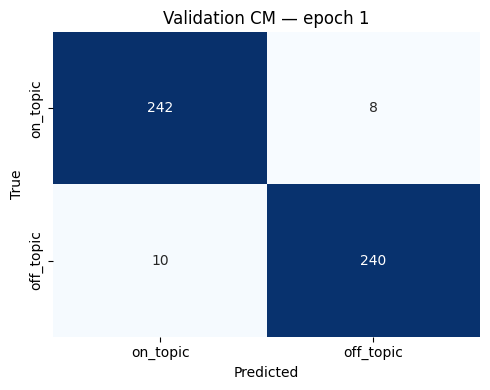

  epoch 1  |  acc=0.9640  f1=0.9639  recall=0.9600  fpr=0.0320


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

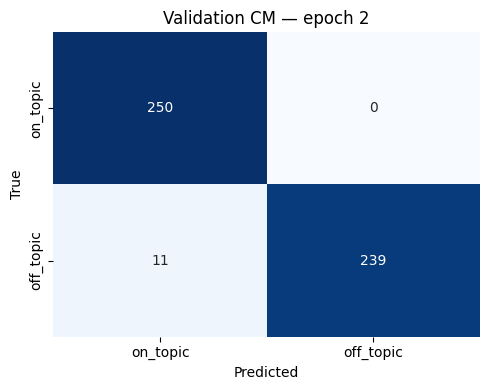

  epoch 2  |  acc=0.9780  f1=0.9775  recall=0.9560  fpr=0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

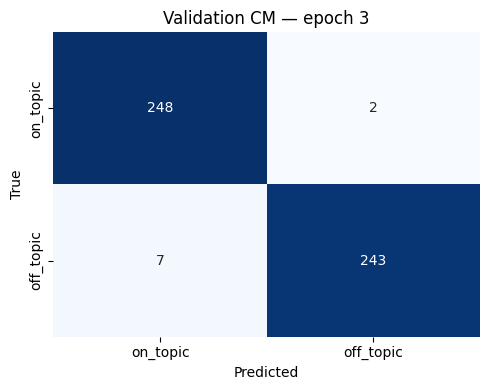

  epoch 3  |  acc=0.9820  f1=0.9818  recall=0.9720  fpr=0.0080


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

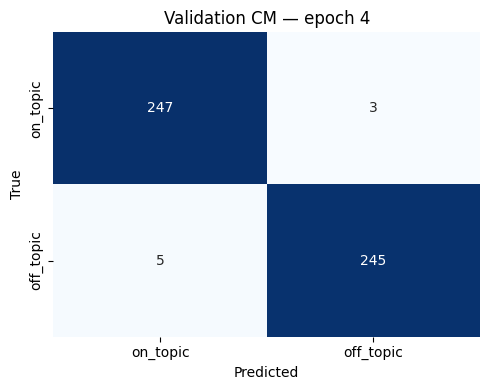

  epoch 4  |  acc=0.9840  f1=0.9839  recall=0.9800  fpr=0.0120


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training finished.
Train runtime: 84.6 sec
Final train loss: 0.1489


In [27]:
# Train — confusion matrix is plotted at the end of every epoch via the callback
train_result = trainer.train()
print("\nTraining finished.")
print(f"Train runtime: {train_result.metrics.get('train_runtime', 0):.1f} sec")
print(f"Final train loss: {train_result.metrics.get('train_loss', 0):.4f}")


## 6. Final evaluation on the 500-row held-out eval set

This is the apples-to-apples comparison against the baseline reported in the README.


VALIDATION SET (held-out 10% of train)


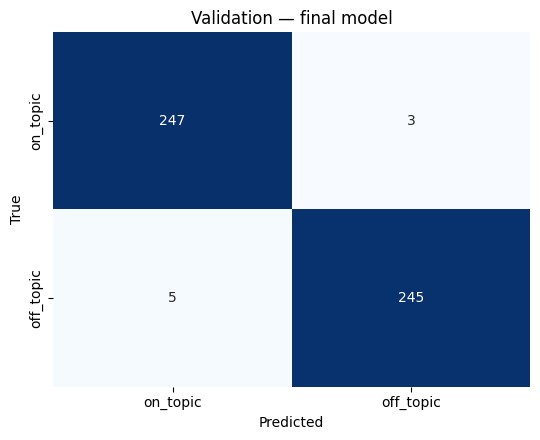

  TN=247  FP=3  FN=5  TP=245
  accuracy           = 0.9840
  recall  (off-topic blocked)        = 0.9800   [baseline 0.30]
  precision (off-topic predictions)  = 0.9879   [baseline 0.93]
  FPR     (on-topic wrongly blocked) = 0.0120   [baseline 0.024]

              precision    recall  f1-score   support

    on_topic     0.9802    0.9880    0.9841       250
   off_topic     0.9879    0.9800    0.9839       250

    accuracy                         0.9840       500
   macro avg     0.9840    0.9840    0.9840       500
weighted avg     0.9840    0.9840    0.9840       500



In [28]:
# Validation set — final state of the best model
print("=" * 60)
print("VALIDATION SET (held-out 10% of train)")
print("=" * 60)
val_pred = trainer.predict(val_ds)
val_preds = np.argmax(val_pred.predictions, axis=1)
val_labels = val_pred.label_ids
plot_cm(val_labels, val_preds, title="Validation — final model")
print("\n" + classification_report(val_labels, val_preds, target_names=LABELS, digits=4))


TEST SET (500-row held-out eval split — comparison with README baseline)


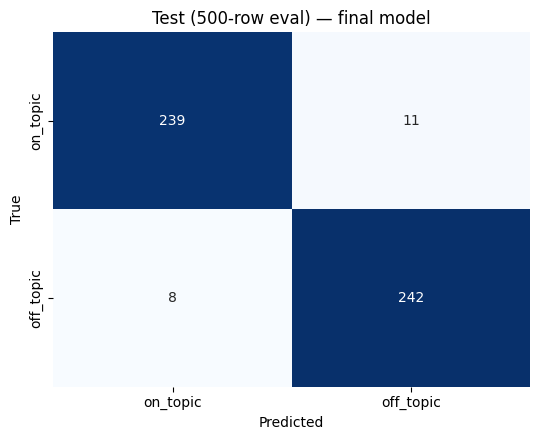

  TN=239  FP=11  FN=8  TP=242
  accuracy           = 0.9620
  recall  (off-topic blocked)        = 0.9680   [baseline 0.30]
  precision (off-topic predictions)  = 0.9565   [baseline 0.93]
  FPR     (on-topic wrongly blocked) = 0.0440   [baseline 0.024]

              precision    recall  f1-score   support

    on_topic     0.9676    0.9560    0.9618       250
   off_topic     0.9565    0.9680    0.9622       250

    accuracy                         0.9620       500
   macro avg     0.9621    0.9620    0.9620       500
weighted avg     0.9621    0.9620    0.9620       500



In [29]:
# Test set — the 500-row eval split, never seen during training
print("=" * 60)
print("TEST SET (500-row held-out eval split — comparison with README baseline)")
print("=" * 60)
test_pred = trainer.predict(test_ds)
test_preds = np.argmax(test_pred.predictions, axis=1)
test_labels = test_pred.label_ids
plot_cm(test_labels, test_preds, title="Test (500-row eval) — final model")
print("\n" + classification_report(test_labels, test_preds, target_names=LABELS, digits=4))


In [30]:
# Per-epoch validation history at a glance
print(f"{'epoch':>6} | {'acc':>7} | {'f1':>7} | {'recall':>7} | {'precision':>9} | {'fpr':>7}")
print("-" * 60)
for h in cm_cb.history:
    m = h["metrics"]
    print(f"{h['epoch']:>6.0f} | {m['eval_accuracy']:>7.4f} | "
          f"{m['eval_f1_offtopic']:>7.4f} | {m['eval_recall_offtopic']:>7.4f} | "
          f"{m['eval_precision_offtopic']:>9.4f} | {m['eval_fpr']:>7.4f}")


 epoch |     acc |      f1 |  recall | precision |     fpr
------------------------------------------------------------
     1 |  0.9640 |  0.9639 |  0.9600 |    0.9677 |  0.0320
     2 |  0.9780 |  0.9775 |  0.9560 |    1.0000 |  0.0000
     3 |  0.9820 |  0.9818 |  0.9720 |    0.9918 |  0.0080
     4 |  0.9840 |  0.9839 |  0.9800 |    0.9879 |  0.0120


## 7. Save model + quick inference

In [31]:
save_path = os.path.join(CONFIG["output_dir"], "best_model")
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Saved to: {save_path}")

# Optional: copy to Google Drive so you don't lose it when the Colab session ends
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r {save_path} /content/drive/MyDrive/input_classifier_best_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./input_classifier_output/best_model


In [32]:
# Quick inference helper for ad-hoc testing
@torch.no_grad()
def classify(system_prompt: str, user_prompt: str):
    model.eval()
    enc = tokenizer(
        system_prompt, user_prompt,
        truncation="longest_first", max_length=CONFIG["max_length"],
        padding=True, return_tensors="pt",
    ).to(model.device)
    logits = model(**enc).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred = int(probs.argmax())
    return {
        "label": LABELS[pred],
        "off_topic_prob": float(probs[1]),
        "on_topic_prob": float(probs[0]),
    }

# Demo
sys_p = (
    "### TASK-BOT ###\n"
    "OBJECTIVE: Provide project management advice for remote teams.\n"
    "Avoid unrelated personal opinions."
)
print("On-topic example:")
print(" ", classify(sys_p, "Tips for evaluating employee performance remotely?"))
print("Off-topic example:")
print(" ", classify(sys_p, "Write me a Python script that scrapes Amazon product listings."))
print("Off-topic example:")
print(" ", classify(sys_p, "What's a good recipe for chocolate chip cookies?"))


On-topic example:
  {'label': 'on_topic', 'off_topic_prob': 0.0003258729411754757, 'on_topic_prob': 0.9996740818023682}
Off-topic example:
  {'label': 'off_topic', 'off_topic_prob': 0.9998152852058411, 'on_topic_prob': 0.00018468432244844735}
Off-topic example:
  {'label': 'off_topic', 'off_topic_prob': 0.9997921586036682, 'on_topic_prob': 0.00020780618069693446}
